In [1]:
# CELL 1: HARDWARE CHECK & DRIVE MOUNT
import tensorflow as tf
from google.colab import drive
import os

print("1. Checking Hardware Connections...")
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    print(f"✅ GPU is active and ready: {physical_devices[0]}")
else:
    print("❌ WARNING: No GPU detected. Evaluation will be extremely slow.")

print("\n2. Mounting Google Drive securely...")
drive.mount('/content/drive')

print("\n3. Verifying Model Access...")
eff_path = '/content/drive/MyDrive/best_efficientnet_B3_nih.keras'
cx_path = '/content/drive/MyDrive/best_convnext_nih.keras'

if os.path.exists(eff_path) and os.path.exists(cx_path):
    print("✅ SUCCESS: Both EfficientNet and ConvNeXt models found in Drive!")
else:
    print("❌ ERROR: Missing models! Check your Drive folder.")

1. Checking Hardware Connections...
✅ GPU is active and ready: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

2. Mounting Google Drive securely...
Mounted at /content/drive

3. Verifying Model Access...
✅ SUCCESS: Both EfficientNet and ConvNeXt models found in Drive!


In [2]:
# CELL 1.5: LOADING THE MODELS INTO ACTIVE GPU MEMORY
from tensorflow.keras.models import load_model

print("1. Waking up EfficientNet-B3... (This takes a few seconds)")
model_eff = load_model(eff_path)
print("✅ EfficientNet-B3 is loaded and ready for inference!")

print("\n2. Waking up ConvNeXt... (This takes a few seconds)")
model_cx = load_model(cx_path)
print("✅ ConvNeXt is loaded and ready for inference!")

1. Waking up EfficientNet-B3... (This takes a few seconds)
✅ EfficientNet-B3 is loaded and ready for inference!

2. Waking up ConvNeXt... (This takes a few seconds)
✅ ConvNeXt is loaded and ready for inference!


In [3]:
# CELL 1: ENVIRONMENT SETUP & DATA LOADING
from google.colab import drive
import zipfile
import os

print("1. Mounting Google Drive...")
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/genuine_capstone_subset.zip'
target_dir = '/content/capstone_eval_set'

print("\n2. Extracting Capstone Validation Subset...")
if os.path.exists(target_dir):
    import shutil
    shutil.rmtree(target_dir)

os.makedirs(target_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(target_dir)

normal_count = len(os.listdir(os.path.join(target_dir, 'Normal')))
effusion_count = len(os.listdir(os.path.join(target_dir, 'Effusion')))

print(f"✅ Dataset Loaded: {normal_count} Normal | {effusion_count} Effusion")

1. Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

2. Extracting Capstone Validation Subset...
✅ Dataset Loaded: 100 Normal | 100 Effusion


1. Initializing Data Generators...
Found 200 images belonging to 2 classes.
Found 200 images belonging to 2 classes.

2. Extracting Probabilities...
200/200 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step

3. Calculating 50/50 Weighted Ensemble...
EfficientNet-B3 Accuracy : 95.50%
ConvNeXt Accuracy        : 97.00%
🔥 FINAL ENSEMBLE        : 98.50%


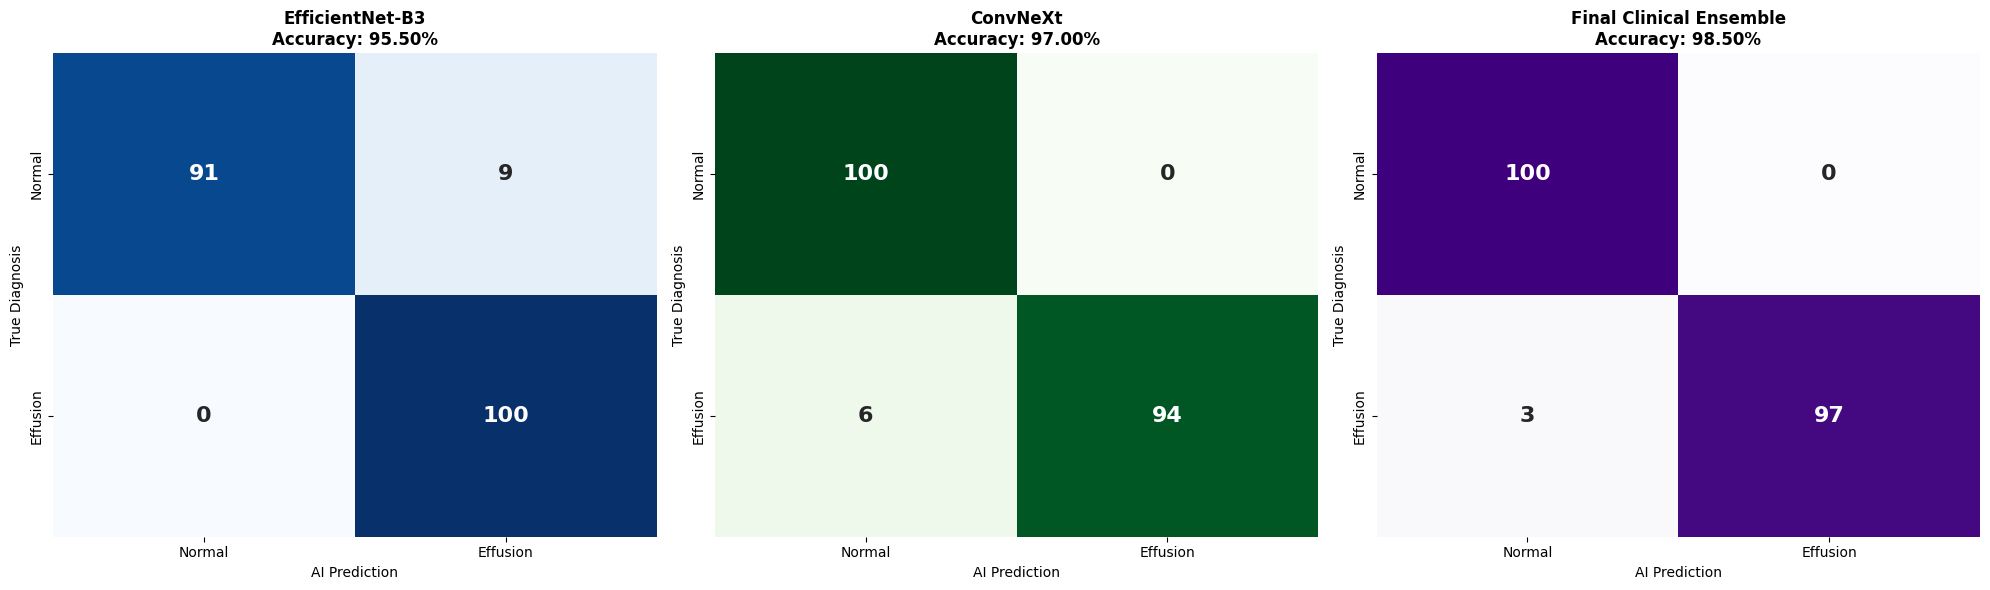

In [4]:
# CELL 3: CLINICAL ENSEMBLE EVALUATION & GRAPHICS
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("1. Initializing Data Generators...")
subset_datagen = ImageDataGenerator()

# Use the exact folder we just unzipped
eff_subset_gen = subset_datagen.flow_from_directory(
    '/content/capstone_eval_set', target_size=(300, 300), batch_size=1,
    class_mode='binary', classes=['Normal', 'Effusion'], shuffle=False
)

cx_subset_gen = subset_datagen.flow_from_directory(
    '/content/capstone_eval_set', target_size=(224, 224), batch_size=1,
    class_mode='binary', classes=['Normal', 'Effusion'], shuffle=False
)

print("\n2. Extracting Probabilities...")
eff_p_sub = model_eff.predict(eff_subset_gen, verbose=1).flatten()
cx_p_sub = model_cx.predict(cx_subset_gen, verbose=1).flatten()
y_true_sub = eff_subset_gen.classes

print("\n3. Calculating 50/50 Weighted Ensemble...")
ens_p_sub = (0.50 * eff_p_sub) + (0.50 * cx_p_sub)

eff_preds = (eff_p_sub > 0.5).astype(int)
cx_preds = (cx_p_sub > 0.5).astype(int)
ens_preds = (ens_p_sub > 0.5).astype(int)

acc_eff = accuracy_score(y_true_sub, eff_preds)
acc_cx = accuracy_score(y_true_sub, cx_preds)
acc_ens = accuracy_score(y_true_sub, ens_preds)

print("=====================================================")
print(f"EfficientNet-B3 Accuracy : {acc_eff*100:.2f}%")
print(f"ConvNeXt Accuracy        : {acc_cx*100:.2f}%")
print(f"🔥 FINAL ENSEMBLE        : {acc_ens*100:.2f}%")
print("=====================================================")

# 4. Generate Graphics
cm_eff = confusion_matrix(y_true_sub, eff_preds)
cm_cx = confusion_matrix(y_true_sub, cx_preds)
cm_ens = confusion_matrix(y_true_sub, ens_preds)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# EfficientNet
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, annot_kws={"size": 16, "weight": "bold"}, xticklabels=['Normal', 'Effusion'], yticklabels=['Normal', 'Effusion'])
axes[0].set_title(f'EfficientNet-B3\nAccuracy: {acc_eff*100:.2f}%', fontweight='bold')
axes[0].set_xlabel('AI Prediction'); axes[0].set_ylabel('True Diagnosis')

# ConvNeXt
sns.heatmap(cm_cx, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False, annot_kws={"size": 16, "weight": "bold"}, xticklabels=['Normal', 'Effusion'], yticklabels=['Normal', 'Effusion'])
axes[1].set_title(f'ConvNeXt\nAccuracy: {acc_cx*100:.2f}%', fontweight='bold')
axes[1].set_xlabel('AI Prediction'); axes[1].set_ylabel('True Diagnosis')

# Ensemble
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='Purples', ax=axes[2], cbar=False, annot_kws={"size": 16, "weight": "bold"}, xticklabels=['Normal', 'Effusion'], yticklabels=['Normal', 'Effusion'])
axes[2].set_title(f'Final Clinical Ensemble\nAccuracy: {acc_ens*100:.2f}%', fontweight='bold')
axes[2].set_xlabel('AI Prediction'); axes[2].set_ylabel('True Diagnosis')

plt.tight_layout()
plt.show()